<a href="https://colab.research.google.com/github/APosokhova893/python_basics/blob/main/%22%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Підготовка даних


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')

In [4]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [5]:
df.shape

(10886, 19)

Набір даних містить 10886 рядків та 19 колонок.Рівень деталізації даних - погодинний, тобто кожен рядок містить інформацію про оренду велосипедів за одну годину.

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [6]:
day_rent = df.groupby("date")["count"].sum()
day_rent

,count
date,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600
...,...
2012-12-15,5047
2012-12-16,3786
2012-12-17,4585


<Axes: title={'center': 'Динаміка оренди велосипедів'}, xlabel='date'>

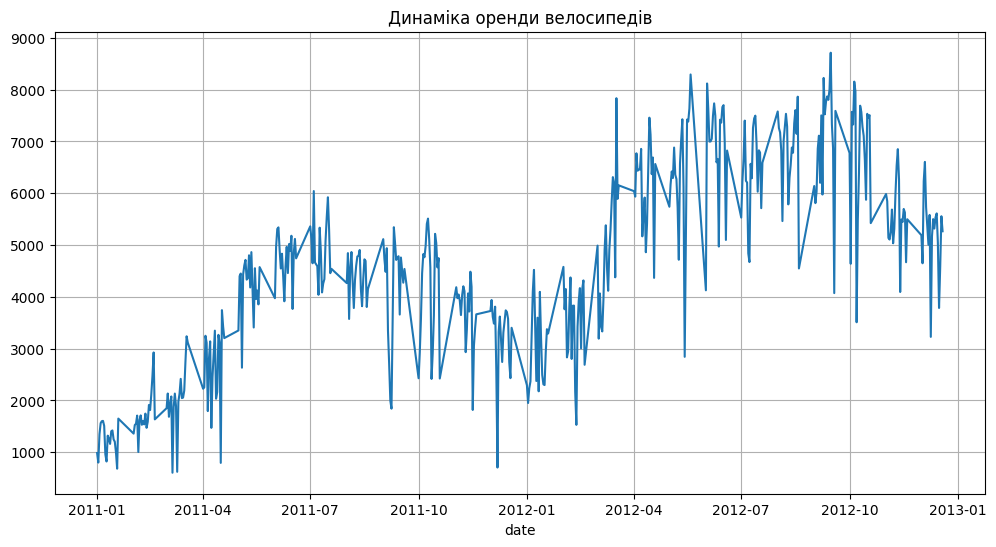

In [7]:
day_rent.plot(figsize=(12,6),
         title= "Динаміка оренди велосипедів",
              grid=True)

In [8]:
date_diff= day_rent.index.to_series().diff()
date_diff

,date
date,
2011-01-01,NaT
2011-01-02,1 days
2011-01-03,1 days
2011-01-04,1 days
2011-01-05,1 days
...,...
2012-12-15,1 days
2012-12-16,1 days
2012-12-17,1 days


In [9]:
date_diff[date_diff> pd.Timedelta(days=1)]

,date
date,
2011-02-01,13 days
2011-03-01,10 days
2011-04-01,13 days
2011-05-01,12 days
2011-06-01,13 days
2011-07-01,12 days
2011-08-01,13 days
2011-09-01,13 days
2011-10-01,12 days


In [10]:
day_rent.idxmin()

datetime.date(2011, 3, 6)

In [11]:
day_rent.min()

605

In [12]:
df[df["date"]==day_rent.idxmin()]

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-03-06 00:00:00,1,0,0,2,17.22,21.210,77,23.9994,11,41,52,2011-03-06,6,9,6,Sunday,2011,3,0
2011-03-06 01:00:00,1,0,0,2,17.22,21.210,77,19.0012,12,27,39,2011-03-06,6,9,6,Sunday,2011,3,1
2011-03-06 02:00:00,1,0,0,2,16.40,20.455,82,19.0012,5,27,32,2011-03-06,6,9,6,Sunday,2011,3,2
2011-03-06 03:00:00,1,0,0,2,17.22,21.210,82,19.9995,2,9,11,2011-03-06,6,9,6,Sunday,2011,3,3
2011-03-06 04:00:00,1,0,0,2,17.22,21.210,88,23.9994,0,3,3,2011-03-06,6,9,6,Sunday,2011,3,4
2011-03-06 06:00:00,1,0,0,2,17.22,21.210,94,23.9994,1,1,2,2011-03-06,6,9,6,Sunday,2011,3,6
2011-03-06 07:00:00,1,0,0,3,17.22,21.210,100,30.0026,0,5,5,2011-03-06,6,9,6,Sunday,2011,3,7
2011-03-06 08:00:00,1,0,0,2,16.40,20.455,100,19.9995,1,8,9,2011-03-06,6,9,6,Sunday,2011,3,8
2011-03-06 09:00:00,1,0,0,2,17.22,21.210,100,19.0012,4,18,22,2011-03-06,6,9,6,Sunday,2011,3,9


Загалом за досліджуваний період спостерігається тенденція до зростання кількості оренд велосипедів: у 2012 році кількість оренд помітно вища, ніж у 2011 році. Також простежується сезонність — у теплі періоди року велосипеди орендують частіше, а в холодні кількість оренд зменшується.
На графіку присутні різкі злами. Під час додаткової перевірки було виявлено, що в датасеті відсутні дані за деякі дні: між останньою наявною датою одного місяця та першою датою наступного є пропуски приблизно у 10–13 днів. Через це лінійний графік з’єднує точки, між якими фактично немає спостережень. Щоб уникнути таких зламів, можна додати відсутні дати та залишити для них значення NaN.
Також на графіку є окремі аномально низькі значення. Наприклад, 6 березня 2011 року було лише 605 оренд. Перевірка даних за цей день показала високу вологість, несприятливі погодні умови та період легкого дощу. Це дозволяє припустити, що погода може суттєво впливати на кількість оренд у деякі дні. Водночас цей день був неробочим, тому низька кількість оренд могла бути спричинена поєднанням кількох факторів.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [13]:
season_rent= df.groupby("season")["count"].mean()
season_rent

,count
season,
1,116.343261
2,215.251372
3,234.417124
4,198.988296


[Text(0, 0, '116.343'),
 Text(0, 0, '215.251'),
 Text(0, 0, '234.417'),
 Text(0, 0, '198.988')]

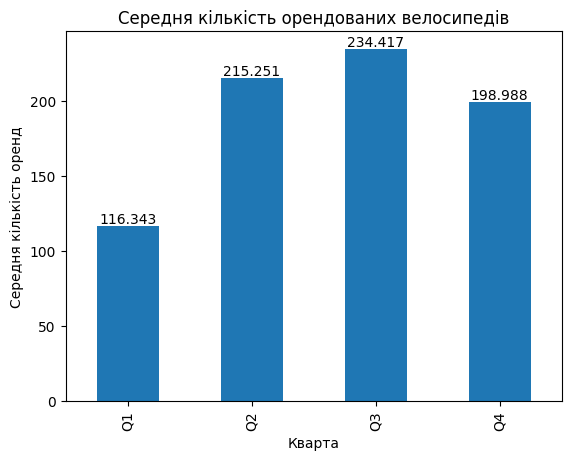

In [14]:
season_rent=season_rent.rename(index={1:"Q1",2:"Q2",3:"Q3",4:"Q4"})
ax=season_rent.plot.bar(
    title="Середня кількість орендованих велосипедів",
    xlabel="Кварта",
    ylabel="Cередня кількість оренд"
)
ax.bar_label(ax.containers[0])


1. Найбільша середня кількість оренд велосипедів спостерігається у Q3 — приблизно 234 оренди на годину. Найменша — у Q1, приблизно 116 оренд на годину.
2. Така сезонна закономірність може бути пов’язана насамперед із погодними умовами та температурою. У тепліші періоди року користуватися велосипедом комфортніше, тому кількість оренд зростає. У холодніший період попит на оренду велосипедів знижується.
3. Середня кількість оренд у найпопулярнішому кварталі Q3 приблизно у 2 рази більша, ніж у найменш популярному Q1:
4. 42 / 116.34 ≈ 2.02 раза.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренд велосипедів на годину по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд у цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


([<matplotlib.axis.XTick at 0x7e789f9051d0>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12')])

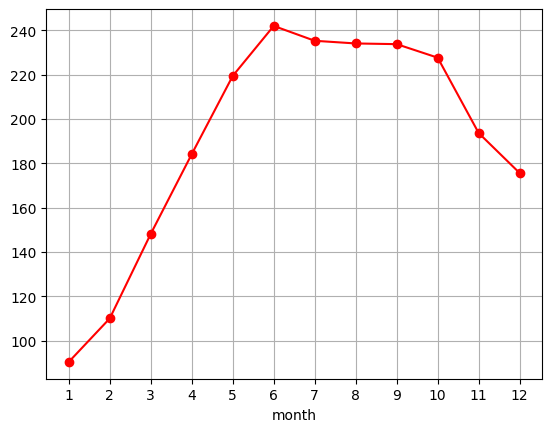

In [15]:
month_rent=df.groupby("month")["count"].mean()
month_rent.plot(
    marker="o",
    grid=True,
    color="red"
)
plt.xticks(range(1,13))

1. Пік оренди велосипедів припадає на червень. Після цього кількість оренд залишається на досить високому рівні, але поступово знижується. Найбільш помітний спад спостерігається у листопаді–грудні, а найнижчий рівень оренди — у січні.
2. Так, ця закономірність загалом збігається з результатами попереднього завдання. Найбільша середня кількість оренд спостерігалася у Q3, і на графіку за місяцями також видно високий рівень оренди в цей період.
3. Клімат та погодні умови можуть суттєво впливати на попит на оренду велосипедів. Несприятливі погодні умови можуть бути причиною зниження кількості оренд, тоді як у періоди з більш комфортною погодою попит на велосипеди зростає.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

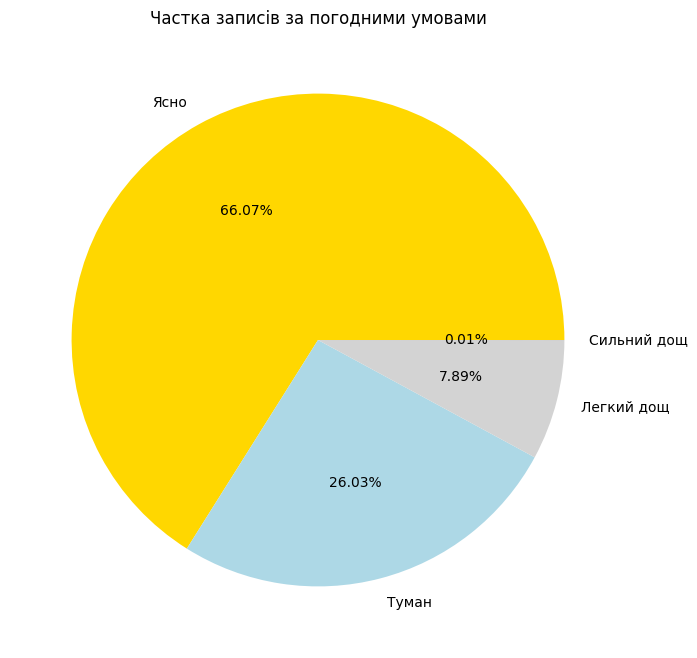

<Axes: title={'center': 'Частка записів за погодними умовами'}, ylabel='count'>

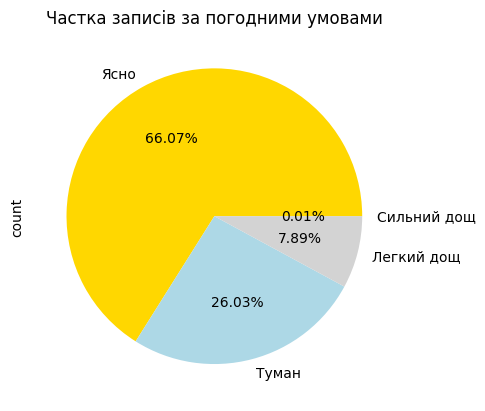

In [16]:
weather_counts=df["weather"].value_counts()
weather_counts.plot.pie(
    autopct="%1.2f%%",
    labels=["Ясно", "Туман", "Легкий дощ", "Сильний дощ"],
    colors=["gold", "lightblue", "lightgray", "darkgray"],
    title="Частка записів за погодними умовами"
)

1.Переважає ясна погода — приблизно 66,07% усіх спостережень.
2.Так, сильний дощ присутній, але лише в 1 записі, що становить приблизно 0,01%.
3.За ясної та комфортної погоди попит на велосипеди, ймовірно, вищий. Дощ та інші несприятливі погодні умови можуть зменшувати кількість оренд, оскільки їздити на велосипеді стає менш комфортно.



## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

([<matplotlib.axis.YTick at 0x7e78974bb110>,
 [Text(0, 1, 'Ясно'),
  Text(0, 2, 'Туман'),
  Text(0, 3, 'Легкий дощ'),
  Text(0, 4, 'Сильний дощ')])

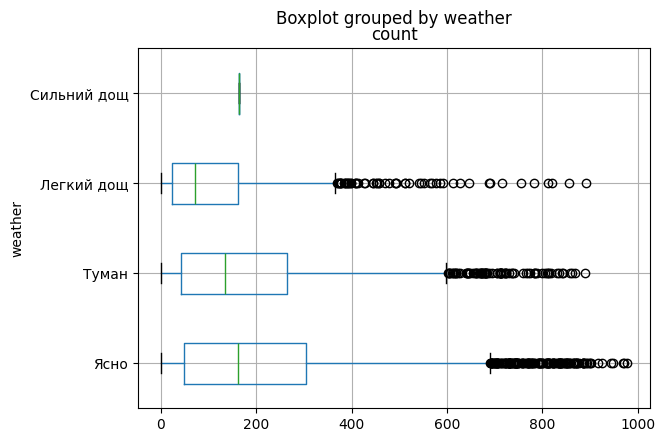

In [19]:
df.boxplot(column="count",by="weather",vert=False)
plt.yticks(
    [1, 2, 3, 4],
    ["Ясно", "Туман", "Легкий дощ", "Сильний дощ"]
)

1.Найбільший розкид спостерігається за ясної погоди.
2.Так, викиди є за ясної погоди, туману та легкого дощу. Для сильного дощу маємо лише одне спостереження.
3.Найвище медіанне значення кількості оренд спостерігається за ясної погоди.


## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

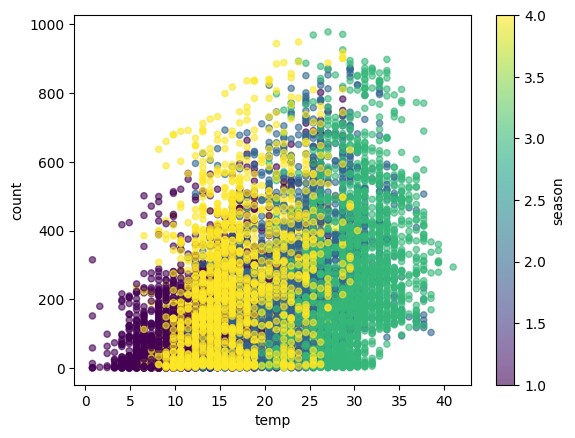

In [20]:
ax = df.plot.scatter(
    x="temp",
    y="count",
    c="season",
    colormap="viridis",
    alpha=0.6
)

Так, спостерігається позитивний зв’язок між температурою та кількістю оренд велосипедів: зі зростанням температури кількість оренд загалом збільшується.

## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [23]:
weekday_users = df.groupby("weekday")[["casual", "registered"]].mean()
weekday_users = weekday_users.reindex([
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
])
weekday_users

,casual,registered
weekday,,
Monday,29.843972,160.546744
Tuesday,22.979207,166.744639
Wednesday,22.521599,165.889749
Thursday,24.007083,173.289118
Friday,31.001962,166.842381
Saturday,63.625000,133.040404
Sunday,57.051298,123.788474


<Axes: xlabel='weekday'>

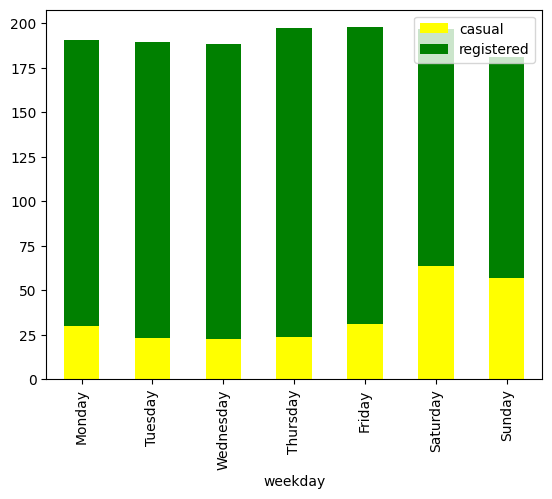

In [26]:
weekday_users.plot.bar(
    stacked=True,
    color= ["yellow","green"]
)

1.Найбільш оренд серед зареєстованих користувачів спостерігається у четвер.
2.Зареєстровані користувачі частіше орендують велосипеди у будні, можливо, використовуючи їх для регулярних поїздок, наприклад на роботу чи навчання. Водночас кількість випадкових користувачів зростає у вихідні, коли велосипеди частіше можуть використовувати для прогулянок і відпочинку.